# *Лабораторная работа №2*

Выполнил: Самойловских Алексей  
Группа: M3234  
Вариант: 62

$f(x)=\begin{cases}0, & x\in[0,1);\\2-x, & x\in[1,2].\end{cases}$

### Часть 2. Численный счет

Формулы частичных сумм из аналитической части:

$$S_N^{\text{общ}}(x)=\frac14+\sum_{k=1}^{N}\left(\frac{1-(-1)^k}{\pi^2k^2}\cos(\pi k(x-1))+\frac{1}{\pi k}\sin(\pi k(x-1))\right).$$

$$S_N^{\sin}(x)=\sum_{k=1}^{N}(-1)^k\left(\frac{2\cos\frac{\pi k}{2}}{\pi k}-\frac{4\sin\frac{\pi k}{2}}{\pi^2k^2}\right)\sin\frac{\pi kx}{2}.$$

$$S_N^{\cos}(x)=\frac14+\sum_{k=1}^{N}(-1)^k\left(\frac{2\sin\frac{\pi k}{2}}{\pi k}+\frac{4\left(\cos\frac{\pi k}{2}-1\right)}{\pi^2k^2}\right)\cos\frac{\pi kx}{2}.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Исходная функция на [0, 2]
def f(x):
    x = np.asarray(x, dtype=float)
    return np.where(x < 1, 0, 2 - x)


# Частичная сумма общего ряда Фурье
def s_general(x, n):
    x = np.asarray(x, dtype=float)
    k = np.arange(1, n + 1)[:, None]
    x_grid = x[None, :]
    a_k = (1 - (-1) ** k) / (np.pi ** 2 * k ** 2)
    b_k = 1 / (np.pi * k)
    return 1 / 4 + np.sum(
        a_k * np.cos(np.pi * k * (x_grid - 1)) +
        b_k * np.sin(np.pi * k * (x_grid - 1)),
        axis=0
    )


# Частичная сумма ряда по синусам
def s_sin(x, n):
    x = np.asarray(x, dtype=float)
    k = np.arange(1, n + 1)[:, None]
    x_grid = x[None, :]
    b_k = (-1) ** k * (
        2 * np.cos(np.pi * k / 2) / (np.pi * k) -
        4 * np.sin(np.pi * k / 2) / (np.pi ** 2 * k ** 2)
    )
    return np.sum(b_k * np.sin(np.pi * k * x_grid / 2), axis=0)


# Частичная сумма ряда по косинусам
def s_cos(x, n):
    x = np.asarray(x, dtype=float)
    k = np.arange(1, n + 1)[:, None]
    x_grid = x[None, :]
    a_k = (-1) ** k * (
        2 * np.sin(np.pi * k / 2) / (np.pi * k) +
        4 * (np.cos(np.pi * k / 2) - 1) / (np.pi ** 2 * k ** 2)
    )
    return 1 / 4 + np.sum(a_k * np.cos(np.pi * k * x_grid / 2), axis=0)


def plot_f(label='f(x)'):
    # Рисуем кусками, чтобы показать скачок в точке x = 1.
    x_left = np.linspace(0, 1, 500, endpoint=False)
    x_right = np.linspace(1, 2, 500)
    plt.plot(x_left, f(x_left), color='black', linewidth=2.5, label=label)
    plt.plot(x_right, f(x_right), color='black', linewidth=2.5)
    plt.scatter([1], [1], color='black', s=30, zorder=5)
    plt.scatter([1], [0], facecolors='white', edgecolors='black', s=38, zorder=5)

### 1. Общий ряд Фурье

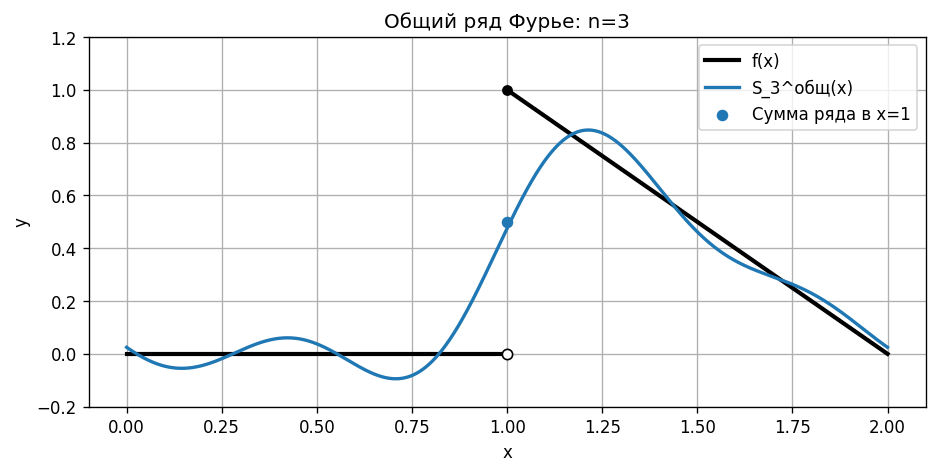

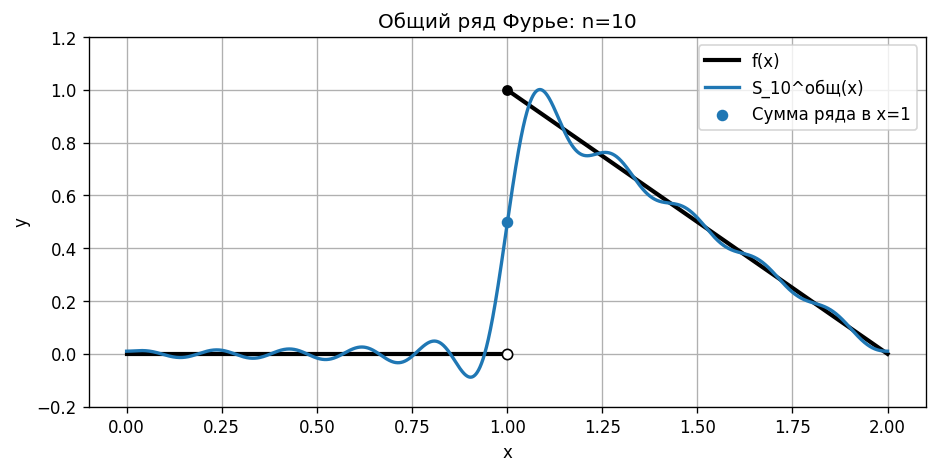

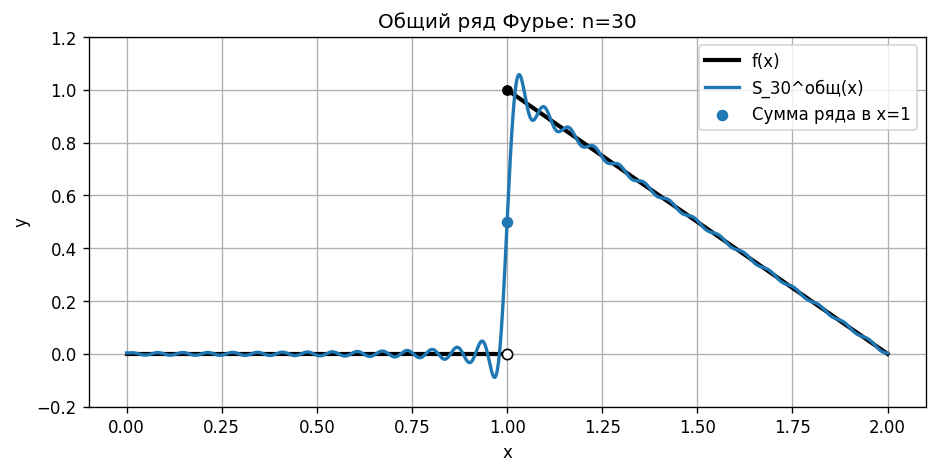

In [ ]:
x = np.linspace(0, 2, 4000)
values = [3, 10, 30]
for n in values:
    plt.figure(figsize=(9, 4))
    plot_f()
    plt.plot(x, s_general(x, n), label=f'S_{n}^общ(x)', linewidth=2)
    plt.scatter([1], [1 / 2], label='Сумма ряда в x=1', s=35, zorder=6)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Общий ряд Фурье: n={n}')
    plt.ylim(-0.2, 1.2)
    plt.legend()
    plt.grid(True)
    plt.show()

### 2. Ряд по синусам

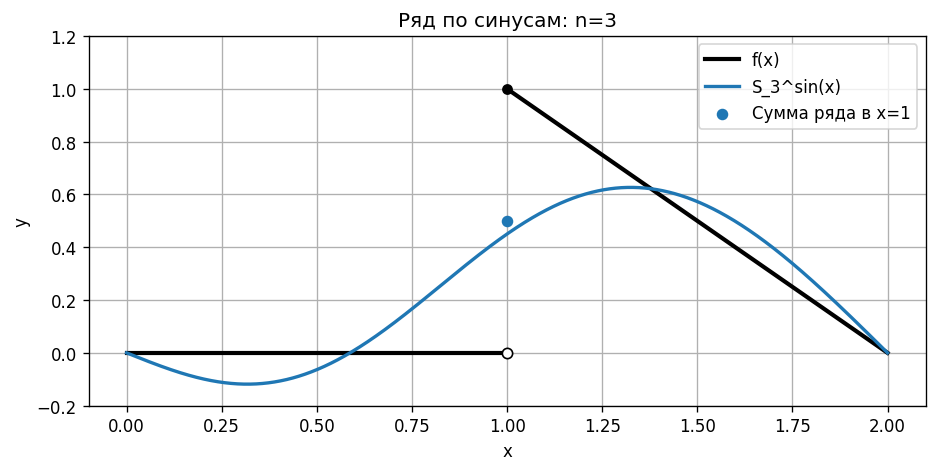

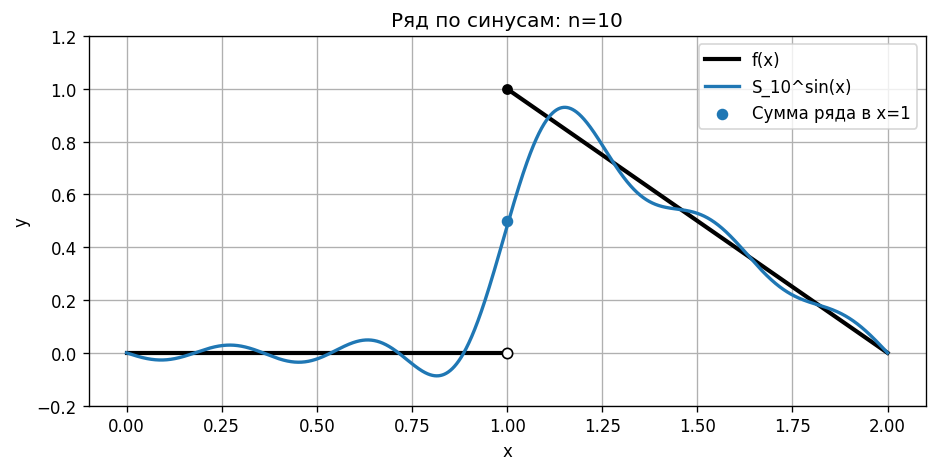

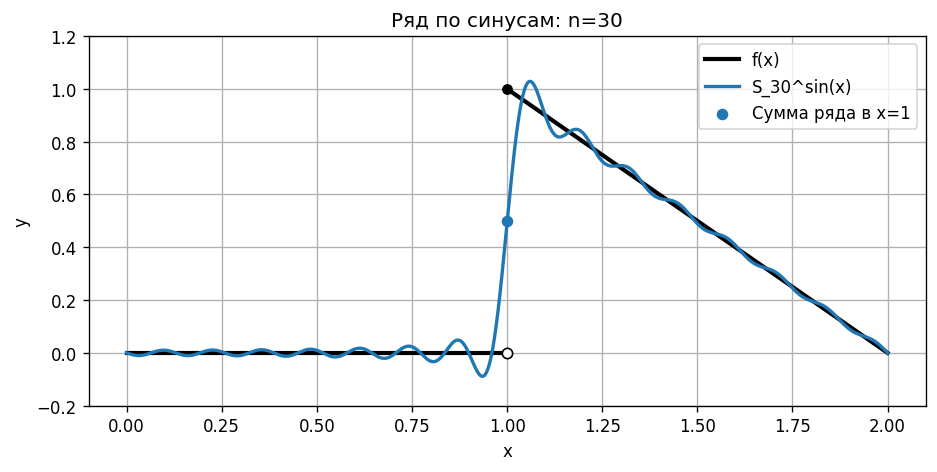

In [ ]:
for n in values:
    plt.figure(figsize=(9, 4))
    plot_f()
    plt.plot(x, s_sin(x, n), label=f'S_{n}^sin(x)', linewidth=2)
    plt.scatter([1], [1 / 2], label='Сумма ряда в x=1', s=35, zorder=6)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Ряд по синусам: n={n}')
    plt.ylim(-0.2, 1.2)
    plt.legend()
    plt.grid(True)
    plt.show()

### 3. Ряд по косинусам

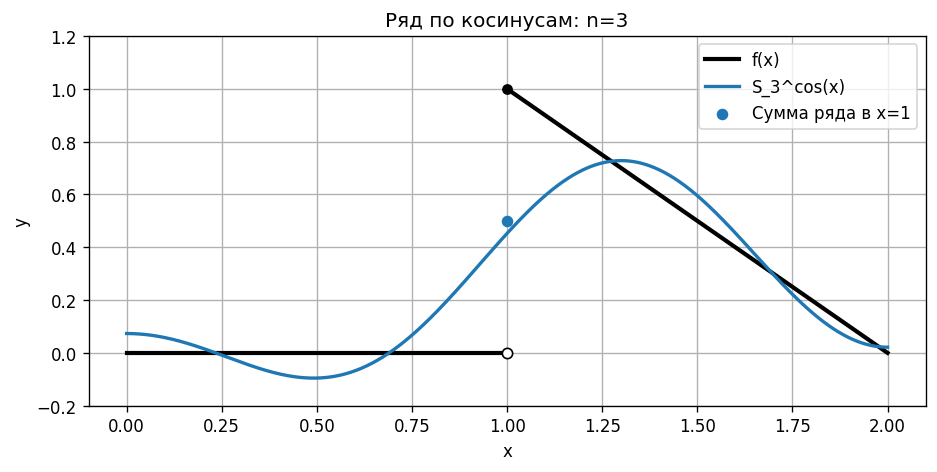

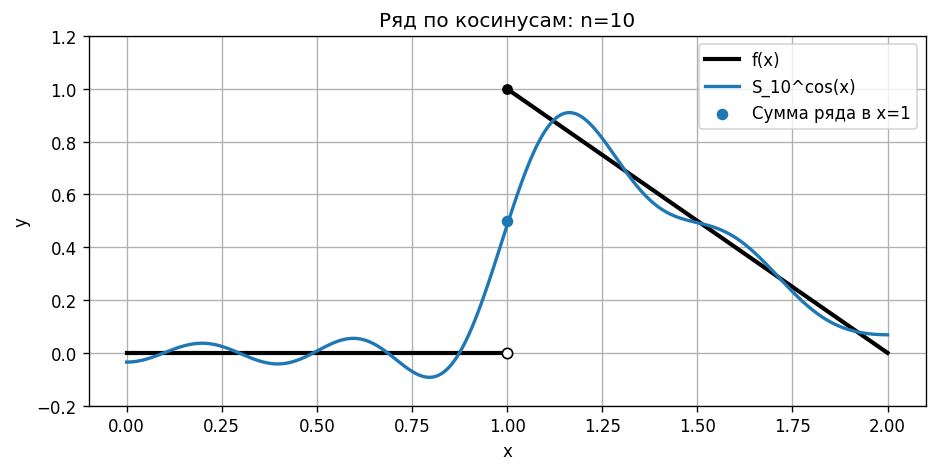

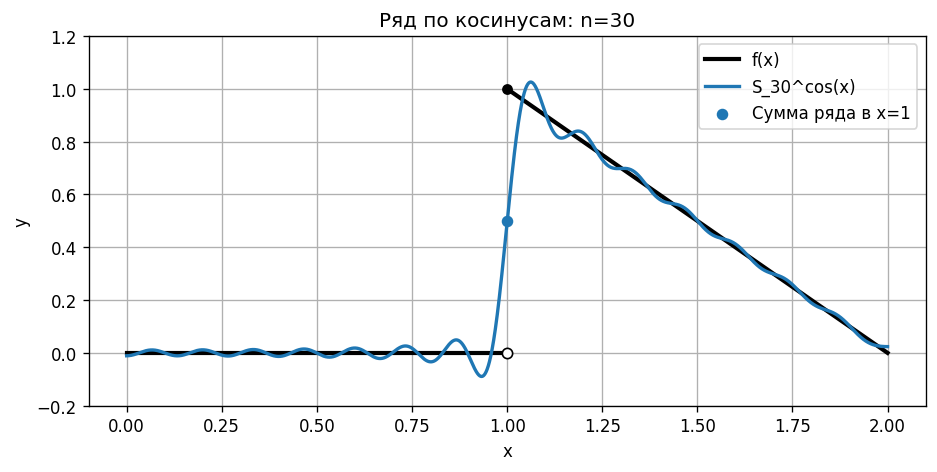

In [ ]:
for n in values:
    plt.figure(figsize=(9, 4))
    plot_f()
    plt.plot(x, s_cos(x, n), label=f'S_{n}^cos(x)', linewidth=2)
    plt.scatter([1], [1 / 2], label='Сумма ряда в x=1', s=35, zorder=6)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Ряд по косинусам: n={n}')
    plt.ylim(-0.2, 1.2)
    plt.legend()
    plt.grid(True)
    plt.show()

### Вывод:  
Я построил графики частичных сумм общего ряда Фурье, ряда по синусам и ряда по косинусам при $n=3,10,30$.  
Сумма ряда Фурье связана с исходной функцией так: во всех точках непрерывности она равна $f(x)$, а в точке скачка равна полусумме односторонних пределов.  
Для данной функции в точке $x=1$: $S(1)=\frac{f(1-0)+f(1+0)}{2}=\frac{0+1}{2}=\frac12$, хотя $f(1)=1$.    
#### ***Спасибо за проверку работы &#10084;***